In [1]:
# Data Manipulation
import pandas as pd 
import numpy as np 

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report

print("All Library is done")


All Library is done


In [2]:
# CSV file load karo
df = pd.read_csv('Titanic-Dataset.csv')

print("Data load Successfully")
print(f'DataSet Shape : {df.shape}')

Data load Successfully
DataSet Shape : (891, 12)


In [3]:
# DataSet ki Basic Info
print("=" * 50)
print("Data Info")
print("=" * 50)
df.info()

print("\n")
print("=" * 50)
print("Basic Statistics")
print("=" * 50)
df.describe()

Data Info
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Basic Statistics


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Missing Value in Each Colunm
Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


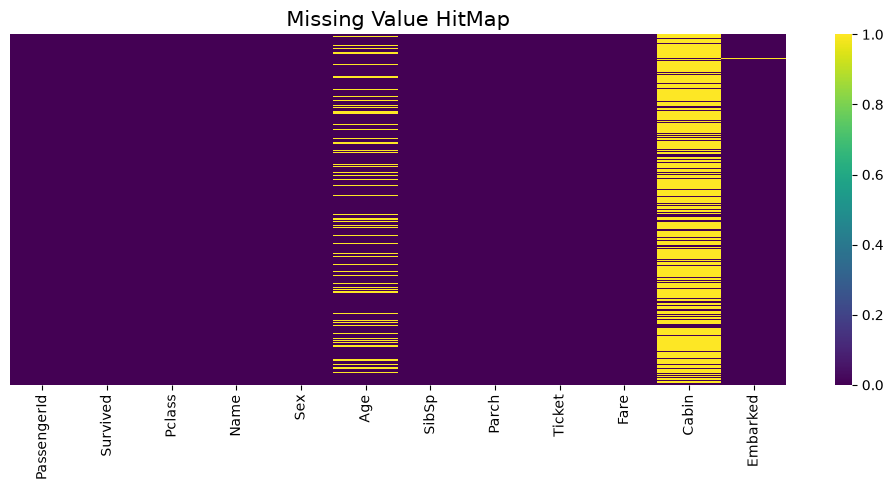

In [4]:
print("=" * 40)
print("Missing Value in Each Colunm")
print("=" * 40)

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Percentange' : missing_percent
})

print(missing_percent[missing_df['Missing Count'] > 0])

# Visualization
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull() , yticklabels=False , cbar=True , cmap='viridis')
plt.title('Missing Value HitMap', fontsize=15)
plt.tight_layout()
plt.show()

In [5]:
# 1. Cabin column drop (77% missing)
df.drop(columns=['Cabin'], inplace=True)
print('Cabin colunm dropped')

#2 Age - Fill From Mean
age_mean = df['Age'].mean()
df['Age'] = df['Age'].fillna(age_mean)
print(f"Age filled with mean: {df['Age'].mean():.2f}")

# 3. Embarked - Mode se fill karo
Embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(Embarked_mode)
print("Embarked filled with mode ")

print("\n Missing Value After Cleaning")
print(df.isnull().sum())

Cabin colunm dropped
Age filled with mean: 29.70
Embarked filled with mode 

 Missing Value After Cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\rp063\AppData\Local\Temp\ipykernel_14796\1225761690.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis', ax=axes[0,0])


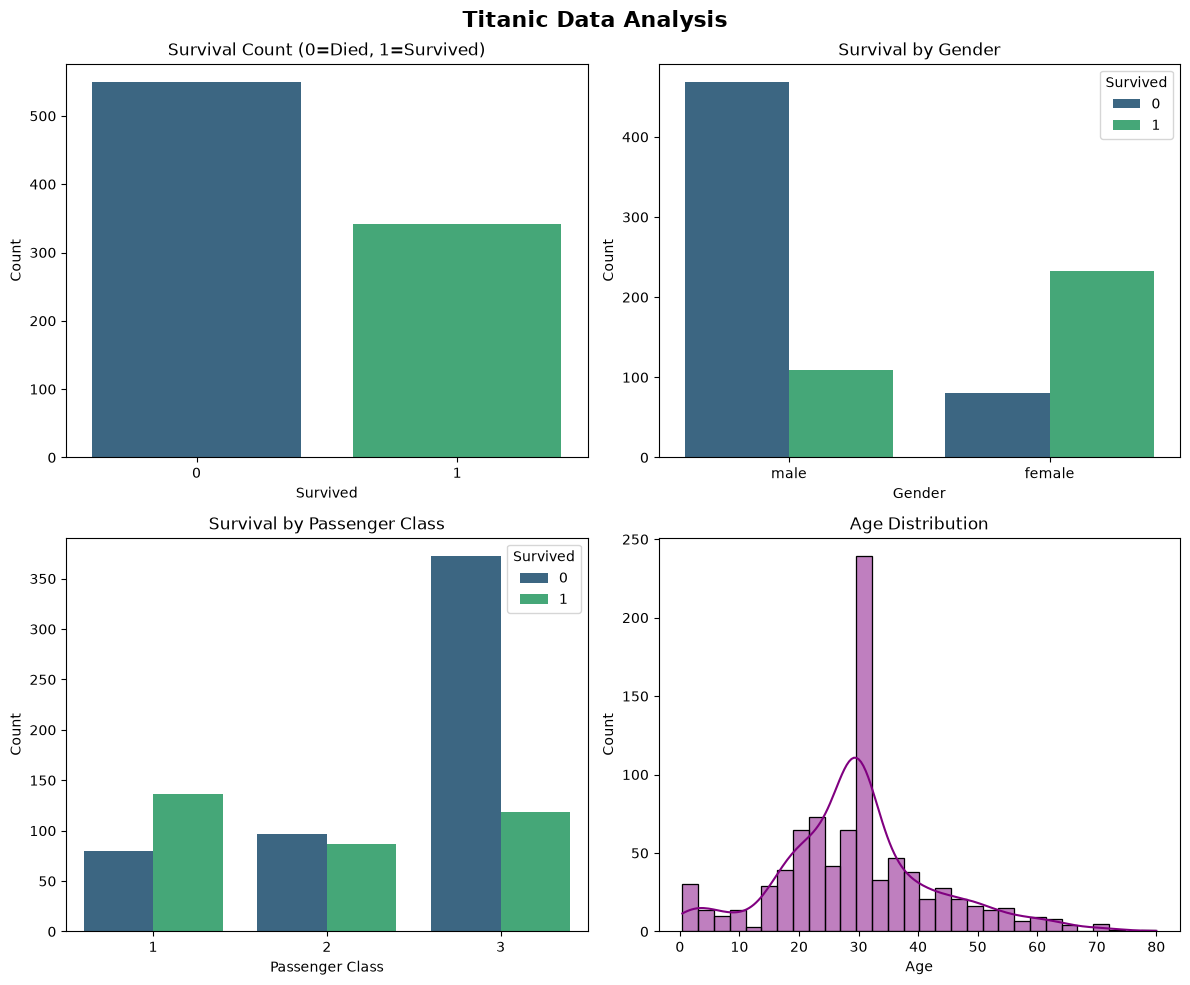

In [6]:
# ============================================
# STEP 6 - DATA VISUALIZATION
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Titanic Data Analysis', fontsize=16, fontweight='bold')

# Graph 1 - Survival Count
sns.countplot(x='Survived', data=df, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Survival Count (0=Died, 1=Survived)')
axes[0,0].set_xlabel('Survived')
axes[0,0].set_ylabel('Count')

# Graph 2 - Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Survival by Gender')
axes[0,1].set_xlabel('Gender')
axes[0,1].set_ylabel('Count')

# Graph 3 - Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis', ax=axes[1,0])
axes[1,0].set_title('Survival by Passenger Class')
axes[1,0].set_xlabel('Passenger Class')
axes[1,0].set_ylabel('Count')

# Graph 4 - Age Distribution
sns.histplot(df['Age'], kde=True, color='purple', ax=axes[1,1])
axes[1,1].set_title('Age Distribution')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
# ============================================
# STEP 7 - FEATURE ENGINEERING
# ============================================

# 1. Name aur Ticket column drop karo (useful nahi)
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])
print(" Useless columns dropped!")

# 2. Sex column encode karo (Male=0, Female=1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
print(" Sex encoded: male=0, female=1")

# 3. Embarked column encode karo
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
print(" Embarked encoded: S=0, C=1, Q=2")

# 4. Final dataset dekho
print("\n Final Dataset:")
print(df.head())
print(f"\n Dataset Shape: {df.shape}")
print(f" Columns: {list(df.columns)}")

 Useless columns dropped!
 Sex encoded: male=0, female=1
 Embarked encoded: S=0, C=1, Q=2

 Final Dataset:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         0
1         1       1    1  38.0      1      0  71.2833         1
2         1       3    1  26.0      0      0   7.9250         0
3         1       1    1  35.0      1      0  53.1000         0
4         0       3    0  35.0      0      0   8.0500         0

 Dataset Shape: (891, 8)
 Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [8]:
# ============================================
# STEP 8 - TRAIN TEST SPLIT
# ============================================

# X = Features (jo denge model ko)
# y = Target (jo predict karna hai)
X = df.drop(columns=['Survived'])
y = df['Survived']

print(f" Features (X) Shape: {X.shape}")
print(f" Target (y) Shape: {y.shape}")
print(f"\n Target Value Counts:")
print(y.value_counts())

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% test, 80% train
    random_state=42     # Reproducibility ke liye
)

print(f"\n Training Set: {X_train.shape}")
print(f" Testing Set:  {X_test.shape}")

 Features (X) Shape: (891, 7)
 Target (y) Shape: (891,)

 Target Value Counts:
Survived
0    549
1    342
Name: count, dtype: int64

 Training Set: (712, 7)
 Testing Set:  (179, 7)


In [9]:
# ============================================
# STEP 9 - MODEL BUILDING
# ============================================

# MODEL 1 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("=" * 45)
print(" MODEL 1 - LOGISTIC REGRESSION")
print("=" * 45)
print(f" Accuracy: {lr_accuracy * 100:.2f}%")

# MODEL 2 - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("\n" + "=" * 45)
print(" MODEL 2 - RANDOM FOREST")
print("=" * 45)
print(f" Accuracy: {rf_accuracy * 100:.2f}%")

# Comparison
print("\n" + "=" * 45)
print(" MODEL COMPARISON")
print("=" * 45)
print(f"Logistic Regression : {lr_accuracy * 100:.2f}%")
print(f"Random Forest       : {rf_accuracy * 100:.2f}%")
winner = "Logistic Regression" if lr_accuracy > rf_accuracy else "Random Forest"
print(f"\n Winner: {winner}")

 MODEL 1 - LOGISTIC REGRESSION
 Accuracy: 79.89%

 MODEL 2 - RANDOM FOREST
 Accuracy: 82.12%

 MODEL COMPARISON
Logistic Regression : 79.89%
Random Forest       : 82.12%

 Winner: Random Forest


 RANDOM FOREST - DETAILED EVALUATION

 Classification Report:
              precision    recall  f1-score   support

        Died       0.83      0.87      0.85       105
    Survived       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



C:\Users\rp063\AppData\Local\Temp\ipykernel_14796\4266204392.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


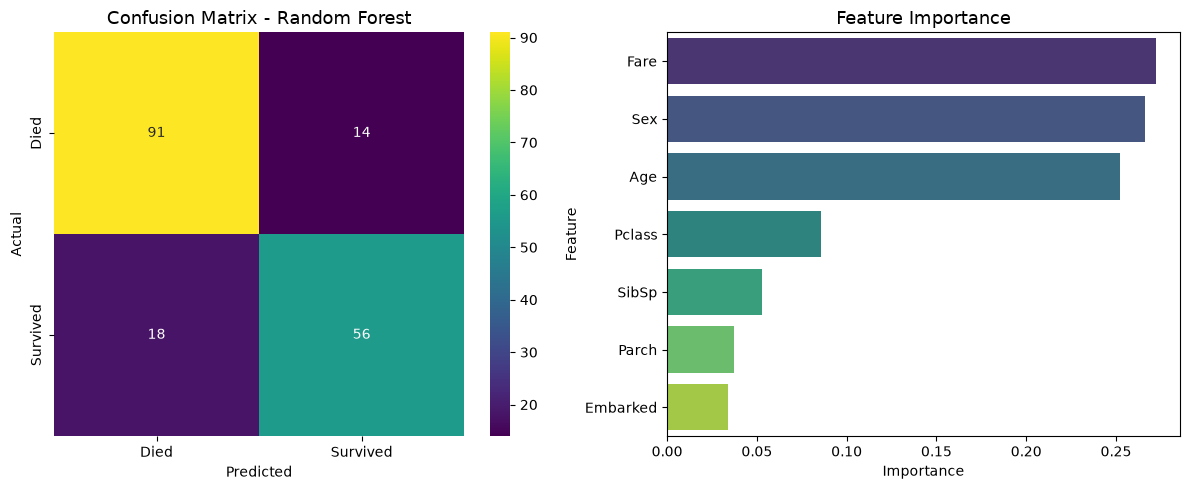


 Feature Importance:
    Feature  Importance
5      Fare    0.272032
1       Sex    0.266227
2       Age    0.252044
0    Pclass    0.085496
3     SibSp    0.052776
4     Parch    0.037304
6  Embarked    0.034121


In [10]:
# ============================================
# STEP 10 - MODEL EVALUATION
# ============================================

print("=" * 50)
print(" RANDOM FOREST - DETAILED EVALUATION")
print("=" * 50)

# 1. Classification Report
print("\n Classification Report:")
print(classification_report(y_test, rf_predictions, 
      target_names=['Died', 'Survived']))

# 2. Confusion Matrix
plt.figure(figsize=(12, 5))

# Confusion Matrix Plot
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix - Random Forest', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')

# 3. Feature Importance
plt.subplot(1, 2, 2)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', 
            data=feature_importance, palette='viridis')
plt.title('Feature Importance', fontsize=13)
plt.tight_layout()
plt.show()

print("\n Feature Importance:")
print(feature_importance)

In [11]:
# ============================================
# STEP 11 - PREDICTION ON NEW DATA
# ============================================

print("🚢 TITANIC SURVIVAL PREDICTOR")
print("=" * 45)

# Naye passengers ka data
new_passengers = pd.DataFrame({
    'Pclass':   [1,      3,      2    ],
    'Sex':      [1,      0,      1    ],  # 1=Female, 0=Male
    'Age':      [25,     30,     22   ],
    'SibSp':    [1,      0,      0    ],
    'Parch':    [0,      0,      0    ],
    'Fare':     [100,    7.5,    30   ],
    'Embarked': [1,      0,      2    ]
})

passengers_info = [
    "Passenger 1: Female, 1st Class, Age 25",
    "Passenger 2: Male,   3rd Class, Age 30", 
    "Passenger 3: Female, 2nd Class, Age 22"
]

predictions = rf_model.predict(new_passengers)
probabilities = rf_model.predict_proba(new_passengers)

print()
for i, (info, pred, prob) in enumerate(
    zip(passengers_info, predictions, probabilities)):
    status = " SURVIVED" if pred == 1 else " DIED"
    survival_prob = prob[1] * 100
    print(f"{info}")
    print(f"Prediction  : {status}")
    print(f"Survival %  : {survival_prob:.1f}%")
    print("-" * 45)

🚢 TITANIC SURVIVAL PREDICTOR

Passenger 1: Female, 1st Class, Age 25
Prediction  :  SURVIVED
Survival %  : 98.0%
---------------------------------------------
Passenger 2: Male,   3rd Class, Age 30
Prediction  :  DIED
Survival %  : 0.0%
---------------------------------------------
Passenger 3: Female, 2nd Class, Age 22
Prediction  :  SURVIVED
Survival %  : 92.0%
---------------------------------------------
